In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
# from catboost import CatBoostRegressor
# from xgboost import XGBRegressor
import warnings

In [19]:
df = pd.read_csv('data/stud.csv')

In [20]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [21]:
# independent and dependent variables

X = df.drop(columns=['math_score'],axis=1)
y = df['math_score']

In [22]:
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

In [23]:
num_features

Index(['reading_score', 'writing_score'], dtype='object')

In [24]:
cat_features

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')

In [25]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder',oh_transformer,cat_features),
        ('StandardScaler',numeric_transformer,num_features),
    ]
)

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [48]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [49]:
X_train_scaled

array([[ 0.        ,  1.        ,  1.        , ...,  0.        ,
        -1.59453623, -0.98844821],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.8575186 ,  0.62886547],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
        -0.33347946, -0.51673172],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
        -0.54365559, -1.05583628],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
        -1.52447752, -1.05583628],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.48804699,  1.37013424]], shape=(750, 19))

In [52]:
def evalute_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true,predicted)

    return mae, rmse, r2

In [54]:
models = {
    'Linear Regression':LinearRegression(),
    'Lasso':Lasso(),
    'Ridge':Ridge(),
    'K-Neighbors Regressor':KNeighborsRegressor(),
    'Decision Tree':DecisionTreeRegressor(),
    'Random Forest Regressor':RandomForestRegressor(),
    'AdaBoost Regressor':AdaBoostRegressor()
}

models_list = []
r2_list = []

for i in range(len(models)):
    model = list(models.values())[i]
    model.fit(X_train_scaled,y_train)

    # Make Prediction
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evalute_model(y_train,y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evalute_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    models_list.append(list(models.keys())[i])

    print(type(model_train_mae))

    print("Model Training performing set")
    print("- Root Mean Squared error: {:.4f}".format(model_train_rmse))
    print("- Mean absolute error: {:.4f}".format(model_train_mae))
    print("- R2 score: {:.4f}".format(model_train_r2))
    print('-' * 40)

    print("Model Testing performing set")
    print("- Root Mean Squared error: {:.4f}".format(model_test_rmse))
    print("- Mean absolute error: {:.4f}".format(model_test_mae))
    print("- R2 score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('=' * 35)
    print('\n')
    
    

Linear Regression
<class 'float'>
Model Training performing set
- Root Mean Squared error: 5.2972
- Mean absolute error: 4.2383
- R2 score: 0.8743
----------------------------------------
Model Testing performing set
- Root Mean Squared error: 5.4825
- Mean absolute error: 4.3379
- R2 score: 0.8778


Lasso
<class 'float'>
Model Training performing set
- Root Mean Squared error: 6.5469
- Mean absolute error: 5.1796
- R2 score: 0.8080
----------------------------------------
Model Testing performing set
- Root Mean Squared error: 6.6501
- Mean absolute error: 5.2184
- R2 score: 0.8202


Ridge
<class 'float'>
Model Training performing set
- Root Mean Squared error: 5.2975
- Mean absolute error: 4.2369
- R2 score: 0.8743
----------------------------------------
Model Testing performing set
- Root Mean Squared error: 5.4790
- Mean absolute error: 4.3355
- R2 score: 0.8780


K-Neighbors Regressor
<class 'float'>
Model Training performing set
- Root Mean Squared error: 5.7484
- Mean absolute 

In [55]:
pd.DataFrame(list(zip(models_list,r2_list)),columns=["Model Name", 'R2 Score']).sort_values(by=['R2 Score'],ascending=False)

,Model Name,R2 Score
2,Ridge,0.877983
0,Linear Regression,0.877824
5,Random Forest Regressor,0.848225
6,AdaBoost Regressor,0.839877
1,Lasso,0.820248
3,K-Neighbors Regressor,0.806001
4,Decision Tree,0.756040


### Linear Regression

In [58]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train_scaled,y_train)
y_pred = lin_model.predict(X_test_scaled)
score = r2_score(y_test,y_pred)
print(score)

0.8778243107659012


Text(0, 0.5, 'predicted')

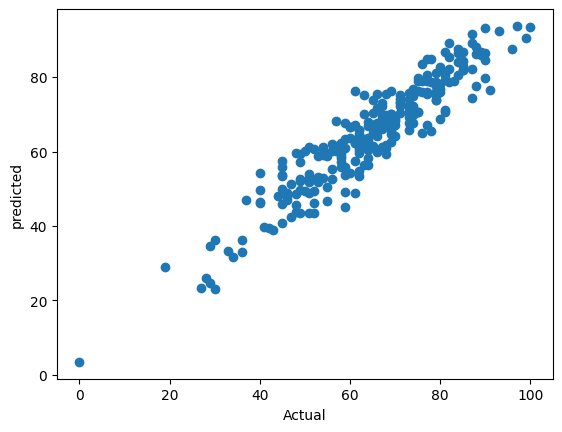

In [59]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("predicted")

<Axes: xlabel='math_score'>

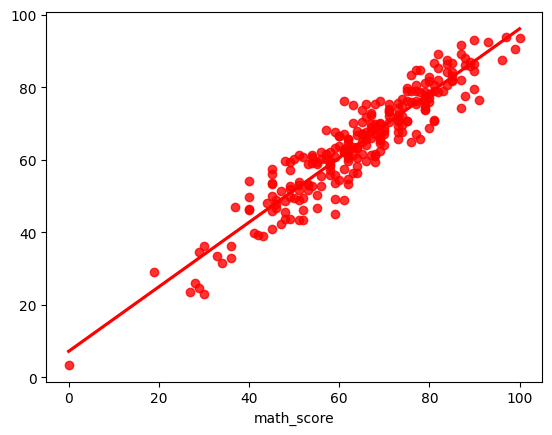

In [61]:
sns.regplot(x=y_test, y=y_pred,color='red',ci=None)

In [63]:
pred_df = pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred })
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.415556,14.584444
737,53,58.835356,-5.835356
740,80,76.907370,3.092630
660,74,76.760032,-2.760032
411,84,87.454007,-3.454007
...,...,...,...
109,70,64.035129,5.964871
430,64,63.158496,0.841504
77,80,82.733853,-2.733853
84,42,39.387374,2.612626
